# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models

# Loading the data file

In [ ]:


file_path = "household_power_consumption.txt"
data = pd.read_csv(
    file_path,
    sep=';',
    low_memory=False
)

print("Original columns:", data.columns)
data.head()

Original columns: Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


# Data preprocessing

In [ ]:

data.replace("?", np.nan, inplace=True)

num_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]


for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")


data.dropna(subset=num_cols, inplace=True)

In [ ]:


data["DateTime"] = pd.to_datetime(
    data["Date"] + " " + data["Time"],
    format="%d/%m/%Y %H:%M:%S"
)
data.set_index("DateTime", inplace=True)
data_features = data[num_cols].copy()

print("Data shape after cleaning:", data_features.shape)
data_features.head()

Data shape after cleaning: (193251, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# Normalizing features

In [ ]:

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_features)


data_scaled = np.array(data_scaled)

# Implementing model
24 minutes sequence window

In [ ]:
def create_windows(series, window_size=24):
    """
    series: 2D array of shape (N, 7)
    window_size: number of past timesteps (24 minutes)

    Returns:
        X: (num_samples, window_size, 7)
        y: (num_samples,)  -> next-minute Global_active_power
    """
    X, y = [], []
    for i in range(window_size, len(series)):

        X.append(series[i-window_size:i, :])

        y.append(series[i, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 24
X, y = create_windows(data_scaled, WINDOW_SIZE)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (193227, 24, 7)
y shape: (193227,)


# Spliting the data

In [ ]:

train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (154581, 24, 7) (154581,)
Test: (38646, 24, 7) (38646,)


# Model summary

In [ ]:

def build_lstm_model(window_size=24, num_features=7, lstm_units=64):
    model = models.Sequential([
        layers.Input(shape=(window_size, num_features)),
        layers.LSTM(lstm_units),
        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model

model = build_lstm_model(WINDOW_SIZE, num_features=7, lstm_units=64)


# Training the model

In [ ]:


history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=150,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
928/928 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - loss: 0.0029 - mae: 0.0289 - val_loss: 8.2603e-04 - val_mae: 0.0131
Epoch 2/20
928/928 ━━━━━━━━━━━━━━━━━━━━ 38s 41ms/step - loss: 0.0011 - mae: 0.0160 - val_loss: 7.7783e-04 - val_mae: 0.0123
Epoch 3/20
928/928 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - loss: 0.0010 - mae: 0.0150 - val_loss: 7.8284e-04 - val_mae: 0.0145
Epoch 4/20
928/928 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - loss: 0.0010 - mae: 0.0150 - val_loss: 7.7654e-04 - val_mae: 0.0131
Epoch 5/20
928/928 ━━━━━━━━━━━━━━━━━━━━ 38s 41ms/step - loss: 0.0010 - mae: 0.0150 - val_loss: 7.3976e-04 - val_mae: 0.0119
Epoch 6/20
928/928 ━━━━━━━━━━━━━━━━━━━━ 34s 37ms/step - loss: 0.0010 - mae: 0.0145 - val_loss: 7.5230e-04 - val_mae: 0.0135
Epoch 7/20
928/928 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - loss: 9.8600e-04 - mae: 0.0148 - val_loss: 7.4000e-04 - val_mae: 0.0120
Epoch 8/20
928/928 ━━━━━━━━━━━━━━━━━━━━ 32s 35ms/step - loss: 9.7412e-04 - mae: 0.0143 - val_loss: 7.1307e-04 - val_mae: 0.0115


# Prediction

In [ ]:
y_pred = model.predict(X_test)


def inverse_global_active_power(scaled_values):
    dummy = np.zeros((len(scaled_values), data_features.shape[1]))
    dummy[:, 0] = scaled_values
    inv = scaler.inverse_transform(dummy)
    return inv[:, 0]

y_test_inv = inverse_global_active_power(y_test)
y_pred_inv = inverse_global_active_power(y_pred.flatten())

1208/1208 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step


# Metrics Evaluation

In [ ]:
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)

print("Test MAE:", mae)
print("Test RMSE:", rmse)


Test MAE: 0.10628467410162158
Test RMSE: 0.23618970159608252


# Base model graph

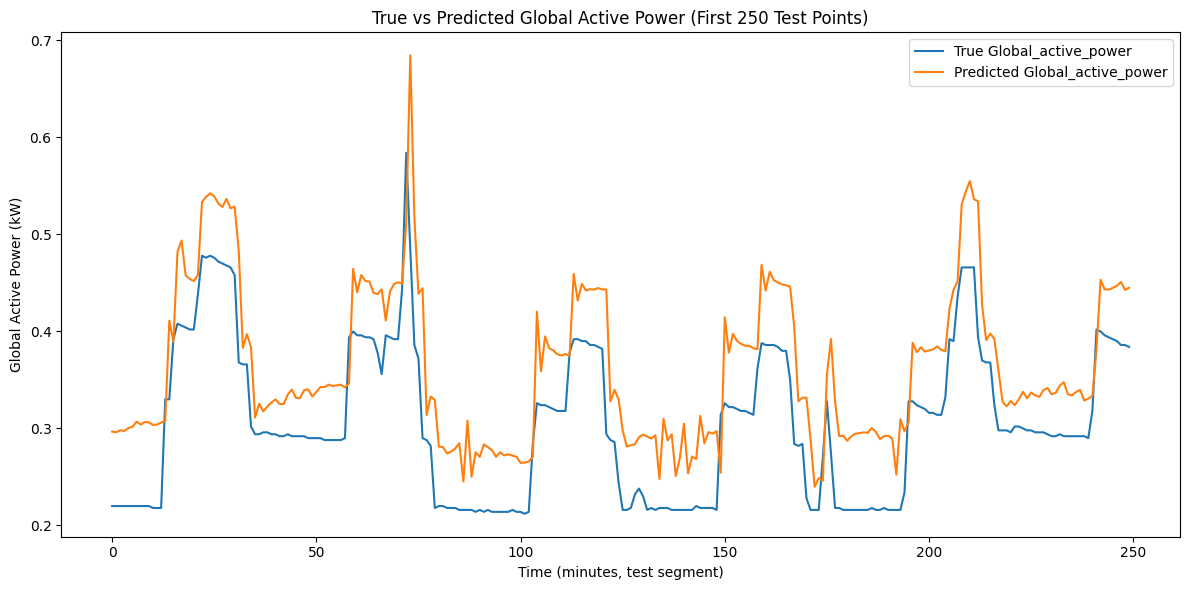

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[:250], label="True Global_active_power")
plt.plot(y_pred_inv[:250], label="Predicted Global_active_power")
plt.xlabel("Time (minutes, test segment)")
plt.ylabel("Global Active Power (kW)")
plt.title("True vs Predicted Global Active Power (First 250 Test Points)")
plt.legend()
plt.tight_layout()
plt.show()

# Tunning the hyperparameters

In [ ]:
results = {}


In [ ]:

WINDOW_SIZE = 60
X, y = create_windows(data_scaled, WINDOW_SIZE)

train_size = int(0.8 * len(X))
X_train_1, X_test_1 = X[:train_size], X[train_size:]
y_train_1, y_test_1 = y[:train_size], y[train_size:]

model_1 = models.Sequential([
    layers.LSTM(64, input_shape=(WINDOW_SIZE, 7)),
    layers.Dense(1)
])
model_1.compile(optimizer="adam", loss="mse", metrics=["mae"])

history_1 = model_1.fit(X_train_1, y_train_1,
                        epochs=30, batch_size=150,
                        validation_split=0.1,
                        verbose=1)

y_pred_1 = model_1.predict(X_test_1)
y_test_inv_1 = inverse_global_active_power(y_test_1)
y_pred_inv_1 = inverse_global_active_power(y_pred_1.flatten())

mae_1 = mean_absolute_error(y_test_inv_1, y_pred_inv_1)
rmse_1 = (mean_squared_error(y_test_inv_1, y_pred_inv_1))**0.5

results["Window-60"] = (mae_1, rmse_1)
print("Experiment-1:", results["Window-60"])


Epoch 1/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 89s 94ms/step - loss: 0.0038 - mae: 0.0325 - val_loss: 8.8846e-04 - val_mae: 0.0137
Epoch 2/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 85s 92ms/step - loss: 0.0012 - mae: 0.0168 - val_loss: 7.7111e-04 - val_mae: 0.0118
Epoch 3/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 148s 98ms/step - loss: 0.0010 - mae: 0.0152 - val_loss: 7.7316e-04 - val_mae: 0.0131
Epoch 4/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 70s 75ms/step - loss: 0.0010 - mae: 0.0150 - val_loss: 7.4662e-04 - val_mae: 0.0117
Epoch 5/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 70s 75ms/step - loss: 0.0010 - mae: 0.0149 - val_loss: 7.4629e-04 - val_mae: 0.0120
Epoch 6/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - loss: 9.9627e-04 - mae: 0.0147 - val_loss: 7.6617e-04 - val_mae: 0.0133
Epoch 7/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 72s 77ms/step - loss: 9.7706e-04 - mae: 0.0147 - val_loss: 7.7082e-04 - val_mae: 0.0128
Epoch 8/30
928/928 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - loss: 9.6290e-04 - mae: 0.0144 - val_loss: 7.4524e-04 - val_mae: 0.

**References**

1. https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/

2. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

3. https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set

4. https://www.researchgate.net/publication/338424977_Electricity_consumption_prediction_based_on_

